In [ ]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re 

In [5]:
result_path = "/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/result_table/"
df = pd.read_csv(result_path+"ptau_pet_model_summary_wCov.csv")

/var/folders/4_/cjf386ls6qbdt4chbrjvnhfm0000gn/T/ipykernel_23450/2763817954.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/4_/cjf386ls6qbdt4chbrjvnhfm0000gn/T/ipykernel_23450/2763817954.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


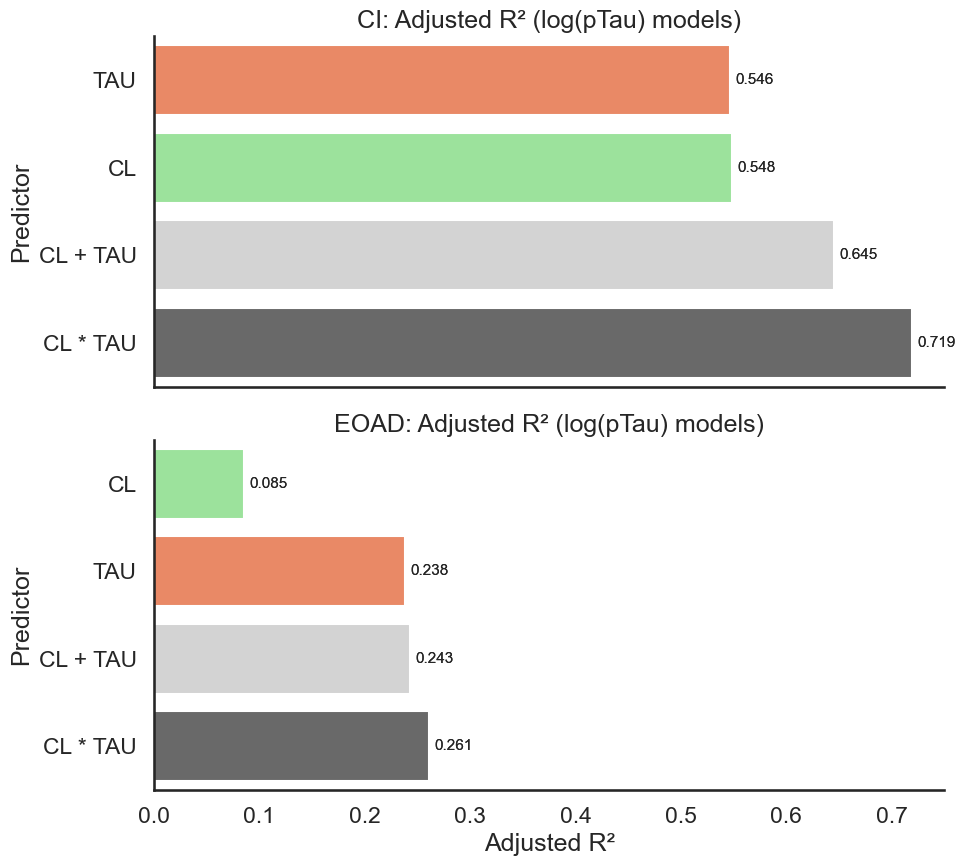

In [ ]:

df2 = df.copy()

# --- Parse model name ---
# Assumes strings like:
# df_base_ci_CL_log(ptau)
# df_base_eoad_CL+TAU_log(ptau)
# df_base_ci_CL*TAU_log(ptau)

def parse_group(model):
    if "df_base_ci" in model:
        return "CI"
    elif "df_base_eoad" in model:
        return "EOAD"
    return None

def parse_predictor(model):
    if "CL * TAU" in model:
        return "CL * TAU"
    if "CL + TAU" in model:
        return "CL + TAU"
    if re.search(" CL ", model):
        return "CL"
    if re.search(" TAU ", model):
        return "TAU"
    return None

def parse_outcome(model):
    m = re.search(r"log\(([^)]+)\)", model)
    return m.group(1) if m else None

df2["group"] = df2["model"].apply(parse_group)
df2["predictor"] = df2["model"].apply(parse_predictor)
df2["outcome"] = df2["model"].apply(parse_outcome)

# Filter outcome = log(ptau)
df_ptau = df2[df2["outcome"].str.lower().eq("ptau")].copy()
df_ptau = df_ptau[df_ptau["group"].isin(["CI", "EOAD"]) & df_ptau["predictor"].notna()]

# Prettier colors
palette = {
    "CL": "lightgreen",
    "TAU": "coral",
    "CL + TAU": "lightgrey",
    "CL * TAU": "dimgray",
}

# Shared x-axis limits across both panels
xmin = 0
xmax = df_ptau["Adjusted R^2"].max()
xpad = (xmax - xmin) * 0.08 if xmax > xmin else 0.05

sns.set(style="white",context="talk") 

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for ax, grp in zip(axes, ["CI", "EOAD"]):
    sub = df_ptau[df_ptau["group"] == grp].copy()

    # Sort bars by Adjusted R^2
    sub = sub.sort_values("Adjusted R^2", ascending=True)

    # Explicit order preserves the sorted order
    order = sub["predictor"].tolist()

    sns.barplot(
        data=sub,
        y="predictor",
        x="Adjusted R^2",
        order=order,
        palette=[palette[p] for p in order],
        errorbar=None,
        ax=ax
    )

    ax.set_title(f"{grp}: Adjusted R² (log(pTau) models)")
    ax.set_xlabel("Adjusted R²")
    ax.set_ylabel("Predictor")
    ax.set_xlim(0,0.75)

    # Annotate values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=4, fontsize=11)

sns.despine(fig=fig, left=False, bottom=False)
plt.tight_layout()
plt.show()